# Predicción de ocurrencia de infarto cerebral 

## 1. Análisis exploratorio de los datos 

In [2]:
# importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# lectura del csv
df = pd.read_csv ("stroke.csv")

In [4]:
# muestra de las 5 primeras filas
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# dimensiones del dataframe 
df.shape

(5110, 12)

El dataframe tiene 12 columnas con las variables de 5110 individuos. 

In [6]:
# información sobre las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


### 1.1 Las variables

### id

In [7]:
# Devuelve True si hay al menos un ID duplicado, False si todos son únicos
df["id"].duplicated().any()

np.False_

#### gender

In [8]:
# Muestra un array con las respuestas únicas
df["gender"].unique()

<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [9]:
# Frecuencia absoluta de cada respuesta
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [10]:
# Frecuencia relativa (porcentajes)
df["gender"].value_counts(normalize=True) * 100

gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: proportion, dtype: float64

### age

In [11]:
# Redondea al entero más cercano y convierte el tipo de dato a entero (int64)
df["age"] = df["age"].round().astype(int)

In [12]:
# Resumen estadístico de la edad
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612731
min         0.000000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

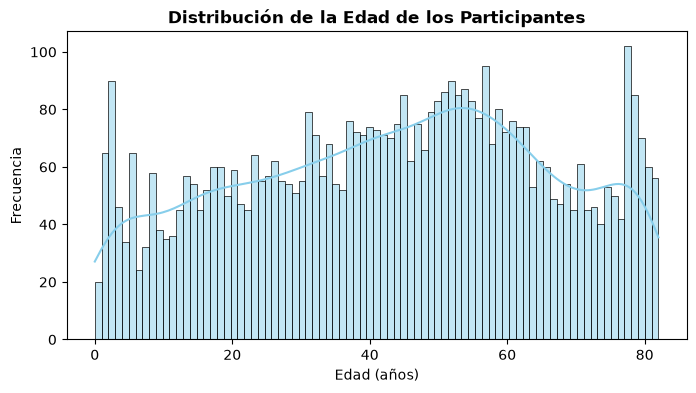

In [13]:
#gráfico para entender la distribución de la edad en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

In [14]:
# Contar número de personas con edad menor a 18
menores_18 = (df["age"] < 18).sum()
porcentaje_menores = (df["age"] < 18).mean() * 100

print(f"Número de menores de 18 años: {menores_18}")
print(f"Porcentaje sobre el total: {porcentaje_menores:.2f}%")

Número de menores de 18 años: 856
Porcentaje sobre el total: 16.75%


In [15]:
# Ver cuántos casos de ictus hay entre los menores de 18 años
df[df["age"] < 18]["stroke"].value_counts()

stroke
0    854
1      2
Name: count, dtype: int64

In [18]:
# 1. Crear una copia filtrada solo con adultos (18 años o más)
df_adultos = df[df["age"] >= 18].copy()

# 2. Verificar las dimensiones de ambos DataFrames
print(f"Filas en el DataFrame original (con menores): {df.shape[0]}")
print(f"Filas en el DataFrame filtrado (solo adultos): {df_adultos.shape[0]}")
print(f"Menores eliminados: {len(df) - len(df_adultos)}")

Filas en el DataFrame original (con menores): 5110
Filas en el DataFrame filtrado (solo adultos): 4254
Menores eliminados: 856


De las 856 personas menores de 18 años, únicamente 2 casos presentan registro de ictus (frente a los 247 casos en adultos). Esta baja prevalencia, sumada a la diferencia etiología del accidente cerebrovascular en pediatría, respalda la decisión metodológica de acotar el estudio a la población adulta (>18 años) para comparar los resultados con el modelo de referencia (Dritsas & Trigka, 2022).

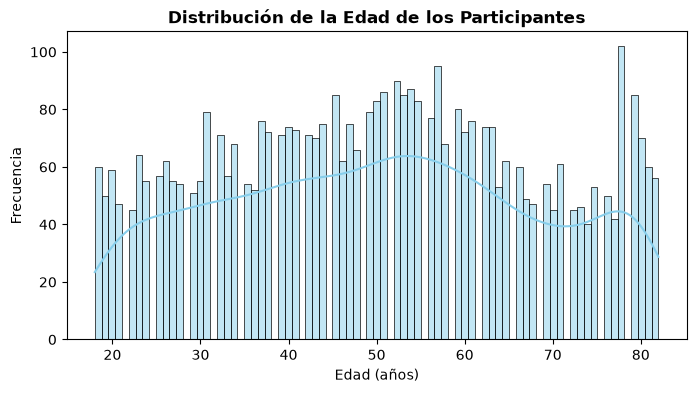

In [19]:
#gráfico para entender la distribución de la edad de los adultos en la muestra
plt.figure(figsize=(8, 4))
sns.histplot(df_adultos["age"], bins=83, kde=True, color="skyblue")
plt.title("Distribución de la Edad de los Participantes", fontsize=12, fontweight="bold")
plt.xlabel("Edad (años)", fontsize=10)
plt.ylabel("Frecuencia", fontsize=10)
plt.show()

Histograma: Distribución de la edad de los participantes adultos
Tras acotar la muestra a la población adulta, el gráfico muestra la distribución de frecuencia por cada año de edad individual (de 18 a 82 años) La muestra cubre de forma continua el espectro adulto desde los 18 hasta los 82 años.   Se observa una mayor densidad de participantes en la franja media-avanzada, concretamente entre los 50 y 60 años, donde se alcanza la cúspide de la curva de estimación de densidad de kernel (KDE).  Destaca un pico pronunciado de frecuencia alrededor de los 78 y 80 años (superando los 100 registros para una sola edad). Esto sugiere un posible sesgo de redondeo o agrupación en la recogida original de datos en pacientes octogenarios.

In [21]:
# 1. Definir los cortes y etiquetas para los rangos de edad
cortes = [18, 25, 35, 45, 55, 65, 75, 83]
etiquetas = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

# 2. Crear la nueva variable de rango de edad en el DataFrame filtrado
df_adultos['age_group'] = pd.cut(df_adultos['age'], bins=cortes, labels=etiquetas, right=False)

# 3. Mostrar tabla de frecuencias absolutas y relativas
tabla_edades = pd.DataFrame({
    'Total Participantes': df_adultos['age_group'].value_counts(sort=False),
    'Porcentaje (%)': (df_adultos['age_group'].value_counts(normalize=True, sort=False) * 100).round(2),
    'Casos de Ictus': df_adultos.groupby('age_group')['stroke'].sum(),
    'Tasa Ictus (%)': (df_adultos.groupby('age_group')['stroke'].mean() * 100).round(2)
})

tabla_edades

,Total Participantes,Porcentaje (%),Casos de Ictus,Tasa Ictus (%)
age_group,,,,
18-24,380,8.93,0,0.00
25-34,609,14.32,1,0.16
35-44,688,16.17,7,1.02
45-54,798,18.76,27,3.38
55-64,752,17.68,53,7.05
65-74,509,11.97,57,11.20
75+,518,12.18,102,19.69


Agrupamiento por rangos de edad:El volumen de participantes por grupo de edad sigue una distribución equilibrada, alcanzando su máximo en la franja de 45 a 54 años (18.76 %). El grupo de edad más avanzada (75+ años) representa un 12.18\% del total (518 individuos), descartando un sesgo de sobrerepresentación en octogenarios.   La tasa de incidencia de ictus muestra un crecimiento posiblemente correlacionado con la edad:   muy baja en menores de 45 años (<1%).   Se sitúa en el 7.05\% entre los 55 y 64 años.   Alcanza el 19.69\% en el grupo de 75+ años, donde prácticamente 1 de cada 5 personas ha sufrido un ictus.   Conclusión: Concentrar la mayoría de los casos positivos de ictus (102 de los 247 totales) en el grupo de mayor edad confirma la coherencia biológica y clínica del dataset para el posterior modelado predictivo.   

### hypertension

In [ ]:
# valores únicos
df["hypertension"].unique()

array([0, 1])

In [ ]:
# Frecuencia relativa (porcentajes)
df["hypertension"].value_counts(normalize=True) * 100

hypertension
0    90.254403
1     9.745597
Name: proportion, dtype: float64

### heart_disease

In [ ]:
# valores único
df["heart_disease"].unique()

array([1, 0])

In [ ]:
# Frecuencia relativa (porcentajes)
df["heart_disease"].value_counts(normalize=True) * 100

heart_disease
0    94.598826
1     5.401174
Name: proportion, dtype: float64

### ever_married

In [ ]:
df["ever_married"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [ ]:
# Mapeo directo de Yes/No a 1/0
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})

In [ ]:
# Frecuencia relativa (porcentajes)
df["ever_married"].value_counts(normalize=True) * 100

ever_married
1    65.616438
0    34.383562
Name: proportion, dtype: float64

### work_type

In [ ]:
df["work_type"].unique()

<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [ ]:
df["work_type"].value_counts(normalize = True) * 100

work_type
Private          57.240705
Self-employed    16.027397
children         13.444227
Govt_job         12.857143
Never_worked      0.430528
Name: proportion, dtype: float64

In [ ]:
# Ver resumen estadístico de la edad para la categoría 'children'
df[df["work_type"] == "children"]["age"].describe()

count    687.000000
mean       6.841339
std        4.536491
min        0.000000
25%        2.000000
50%        6.000000
75%       11.000000
max       16.000000
Name: age, dtype: float64

In [ ]:
# Frecuencia absoluta y relativa de infarto cerebral 
pd.crosstab(df["work_type"], df["stroke"], margins=True, normalize="index") * 100

stroke,0,1
work_type,,
Govt_job,94.977169,5.022831
Never_worked,100.000000,0.000000
Private,94.905983,5.094017
Self-employed,92.063492,7.936508
children,99.708879,0.291121
All,95.127202,4.872798


### Residence-type

In [ ]:
df["Residence_type"].unique()

<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [ ]:
# Ponemos el nombre de la columna en minuscula para normalizar 
df = df.rename(columns={"Residence_type": "residence_type"})

In [ ]:
# frecuencias relativas
df["residence_type"].value_counts(normalize = True) * 100

residence_type
Urban    50.802348
Rural    49.197652
Name: proportion, dtype: float64

### avg_glucose_level

In [ ]:
df["avg_glucose_level"].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

### bmi

In [ ]:
df ["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [ ]:
# Presencia de valores nulos
print(f"Valores nulos en BMI: {df["bmi"].isnull().sum()} ({df["bmi"].isnull().mean()*100:.2f}%)")

Valores nulos en BMI: 201 (3.93%)


### smoking_status

In [ ]:
df["smoking_status"].unique()

<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [ ]:
# frecuencias relativas en porcentaje
df["smoking_status"].value_counts(normalize=True) * 100

smoking_status
never smoked       37.025440
Unknown            30.215264
formerly smoked    17.318982
smokes             15.440313
Name: proportion, dtype: float64

### stroke

In [ ]:
df["stroke"].unique()

array([1, 0])

In [ ]:
# frecuencias relativas en porcentaje
df["stroke"].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [ ]:
# Distribución de ictus en la muestra de adultos
print(df_adults["stroke"].value_counts())
print("\nPorcentaje de ictus en adultos:")
print(df_adults["stroke"].value_counts(normalize=True) * 100)

stroke
0    4007
1     247
Name: count, dtype: int64

Porcentaje de ictus en adultos:
stroke
0    94.1937
1     5.8063
Name: proportion, dtype: float64
